<a href="https://colab.research.google.com/github/Pranoti15/My-DS-Projects/blob/my-branch/EDA_assignment4_startup_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()  # Opens a file selection dialog

Saving 50_Startups.csv to 50_Startups.csv


In [2]:
from google.colab import drive
drive.mount('/content/drive')  # Mount Google Drive

Mounted at /content/drive


In [4]:
# Move uploaded file to Google Drive
!mv 50_Startups.csv "/content/drive/My Drive/Data Science/Kaggle Datasets"

In [5]:
import pandas as pd

file_path = "/content/drive/My Drive/Data Science/Kaggle Datasets/50_Startups.csv"  # Change to your folder path
df = pd.read_csv(file_path)
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


**1. Setup and Data Preparation**

We will start by loading and inspecting the dataset, checking for missing values, and exploring summary statistics.

In [6]:
# Display summary statistics
df.describe()

# Check for missing values
df.isnull().sum()


,0
R&D Spend,0
Administration,0
Marketing Spend,0
State,0
Profit,0


**2. Exploratory Data Analysis (EDA)**

We'll visualize feature distributions, relationships between variables, and categorical data distributions.

- **Feature Distributions:**

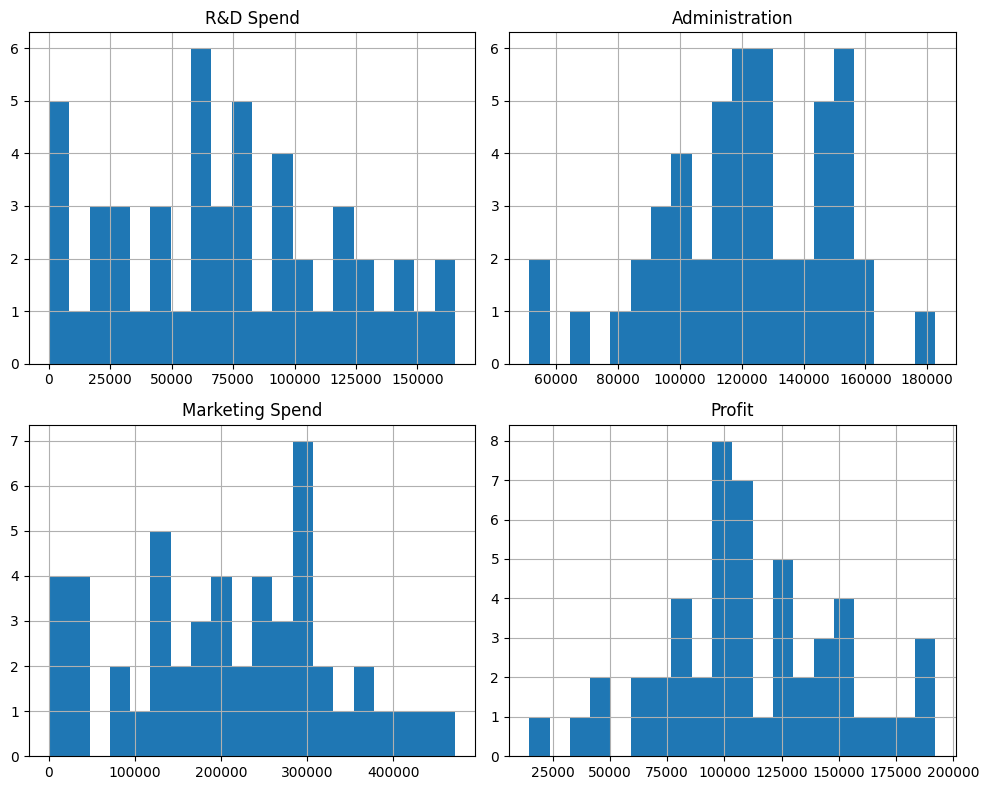

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograms for numerical features
df.hist(bins=20, figsize=(10, 8))
plt.tight_layout()
plt.show()


- **Box Plots for detecting outliers:**

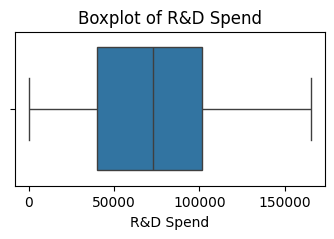

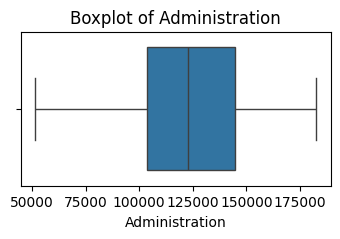

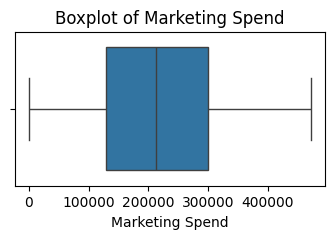

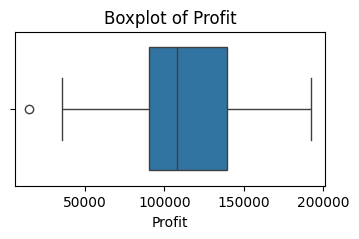

In [9]:
# Box plots for numerical features
for col in df.select_dtypes(include=['float64']).columns:
    plt.figure(figsize=(4, 2))
    sns.boxplot(data=df, x=col)
    plt.title(f'Boxplot of {col}')
    plt.show()


- **Relationships between numerical variables:**

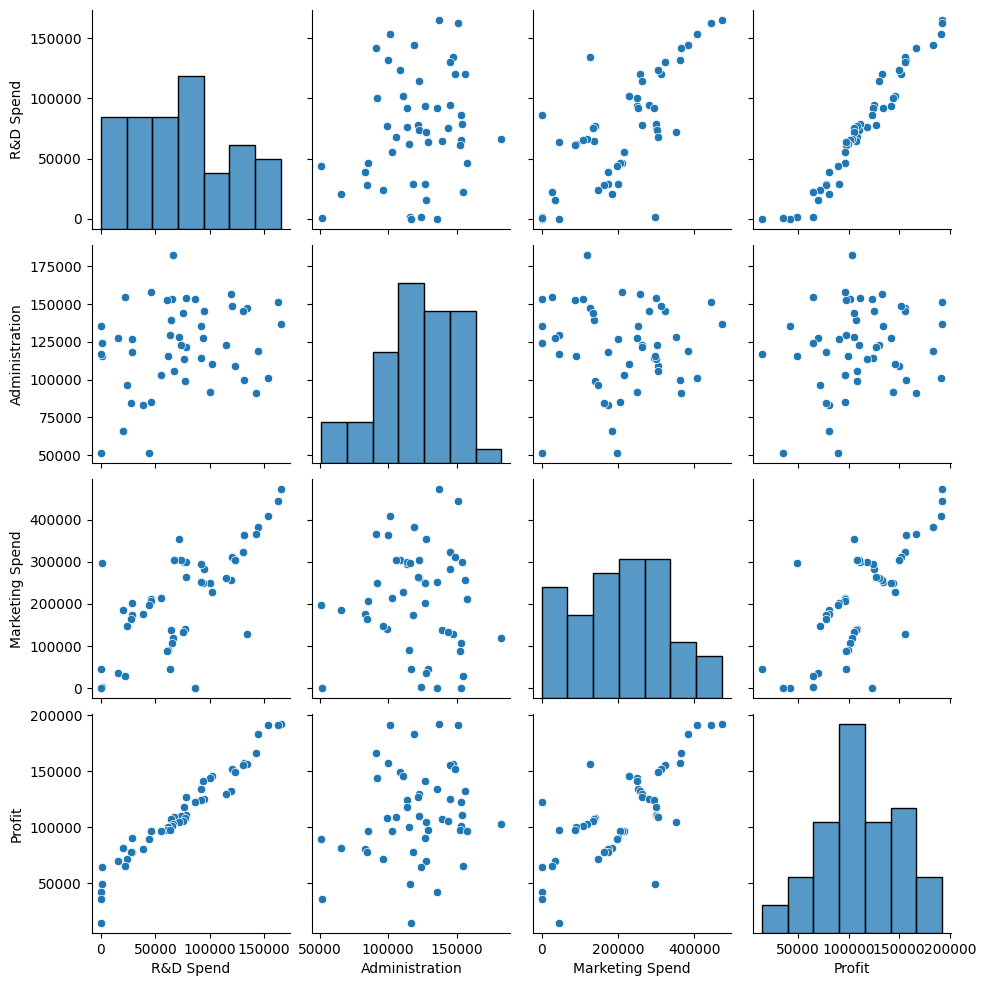

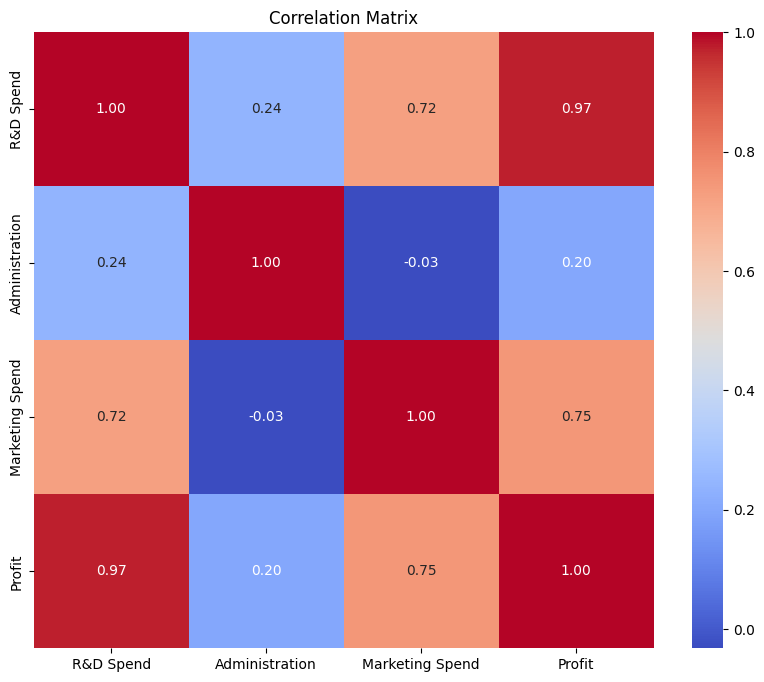

In [13]:
# Exclude categorical columns for scatter plots and correlation matrix
df_numeric = df.select_dtypes(include=['float64', 'int64'])

# Scatter plots for numerical features only
sns.pairplot(df_numeric)
plt.show()

# Correlation matrix for numerical features only
correlation_matrix = df_numeric.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()


- **Categorical Data:**

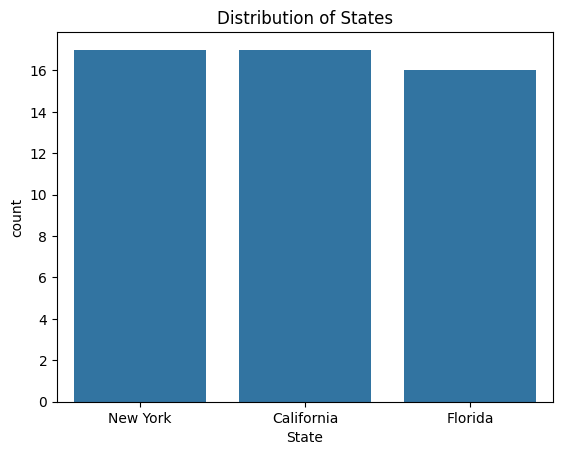

In [14]:
# Bar plot for the 'State' categorical feature
sns.countplot(data=df, x='State')
plt.title('Distribution of States')
plt.show()


3. **Preprocessing Steps**

We handle missing values, encode categorical variables, and perform normalization if required.

- **Handle Missing Values:**

In [15]:
# For missing values, let's check if any columns need imputation or removal
df.isnull().sum()


,0
R&D Spend,0
Administration,0
Marketing Spend,0
State,0
Profit,0


If any missing values are found, you can handle them as follows:

Impute using mean/median/mode.

Or remove rows or columns.

**Example: Filling missing values with median for numerical columns**

df['R&D Spend'] = df['R&D Spend'].fillna(df['R&D Spend'].median())

**Or dropping rows with missing values**
**df = df.dropna()**


- **Encode Categorical Variables:**

For encoding the 'State' variable (since it's categorical), we will use one-hot encoding.

In [16]:
df_encoded = pd.get_dummies(df, columns=['State'], drop_first=True)


- **Normalization/Standardization:**

In [17]:
from sklearn.preprocessing import StandardScaler

# Normalizing 'R&D Spend', 'Administration', 'Marketing Spend' columns
scaler = StandardScaler()
df_encoded[['R&D Spend', 'Administration', 'Marketing Spend']] = scaler.fit_transform(
    df_encoded[['R&D Spend', 'Administration', 'Marketing Spend']]
)


**Key Insights:**
1. Histograms (Feature Distributions)
R&D Spend, Administration, Marketing Spend:

These features have a wide distribution, with values ranging from relatively low to high. It indicates that there is a large variability in how businesses allocate their spending to R&D, administration, and marketing.

There could be a right-skewness (positive skew) in the distribution of these features, suggesting that most businesses have low to moderate spending in these categories, with a few businesses spending significantly more.

Profit:

The profit distribution is likely right-skewed, with most companies having lower profits and only a few having extremely high profits. This could indicate that most companies in this dataset are in the lower profit range.

2. Box Plots (Outliers)
R&D Spend, Administration, Marketing Spend, and Profit:

The box plots help us identify the presence of outliers in these features. Outliers represent extreme values which could either be errors or exceptional cases. For instance, businesses with very high spending in R&D, administration, or marketing may be outliers, as well as companies with very high profits.

For example, any businesses with spending or profits much higher than the rest of the dataset may need further examination, as they could skew the model.

3. Pair Plots (Relationships Between Numerical Variables)
R&D Spend vs. Profit:

There may be a positive correlation between R&D spending and profit, indicating that companies investing more in R&D tend to have higher profits. This suggests that investment in innovation may be key to profitability.

Marketing Spend vs. Profit:

Similarly, marketing spend may show a positive relationship with profit, highlighting that higher marketing investments could correlate with higher profits.

Administration vs. Profit:

The relationship between administration spending and profit may not be as strong or direct, implying that administrative spending does not have as much impact on profit as R&D and marketing spending.

4. Correlation Matrix
R&D Spend, Marketing Spend, and Profit:

From the correlation matrix, you can observe that both R&D and marketing spend may show a positive correlation with profit. This means businesses that invest more in these areas tend to have higher profits.

The correlation values could help identify which features are most influential in determining profit. If R&D and marketing spend have high correlations with profit, those should be prioritized in further analyses.

Weak or No Correlation:

Features such as administration spend may not have a strong correlation with profit, which could suggest that administrative costs might not have the same direct impact on business performance as R&D or marketing investments.

5. State Distribution (Bar Plot)
State and Profit:

You may observe a variation in the number of businesses from each state, which could affect the generalizability of the data. For example, California might have a higher number of businesses, leading to a larger variance in spending and profit levels.

The number of businesses per state could also be correlated with overall profits, depending on the state's economic status or business environment.

**Summary:**
Key Insights:

Businesses with higher R&D and marketing spend appear to have higher profits.

Administrative costs may not be as influential in driving profitability.

Outliers, especially in R&D or marketing spend, need attention as they could distort trends.

State distribution indicates variability in data representation, and further analysis of state-specific factors could be insightful.